# FINAL TERM EXAMINATION - Data Wrangling
**Author:** Leroy Christopher Gerson
**Dataset:** Medical Appointment No Shows (Behavioral Patient Analytics)

## 0. SETUP & IMPORTS

In [1]:
# Import required libraries for data manipulation and visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Data Understanding
Performing initial exploratory data analysis (EDA) to understand the dataset's dimensions, features, and target labels.


In [2]:
# Load the Kaggle dataset from the local directory
raw_df = pd.read_csv('data/noshowappointments.csv')

# Display baseline structural configuration and data types
print(f"Dataset dimensions: {raw_df.shape[0]} rows and {raw_df.shape[1]} columns.\n")
print("--- Data Type Information ---")
raw_df.info()

display(raw_df.head())

Dataset dimensions: 110527 rows and 14 columns.

--- Data Type Information ---
<class 'pandas.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  str    
 3   ScheduledDay    110527 non-null  str    
 4   AppointmentDay  110527 non-null  str    
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  str    
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  str    
dtypes: float64(1), int64(8), str(5)
memory usage: 17.6 MB


,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


### 1.1 Brief Dataset Description
This dataset has been encoded and separated into two components: Features (Gender, ScheduledDay, AppointmentDay, Age, Neighbourhood, Scholarship, Hypertension, Diabetes, Alcoholism, Handicap, SMS_received) and Target Label (No-show).

These features represent a patient profile for individuals scheduling a hospital appointment, while the label indicates whether the patient actually attended.

The analysis will examine why many patients schedule appointments but do not show up, considering factors such as scheduling lead time, age, location, insurance-like scholarship support, medical conditions, and receipt of confirmation messages.

A general cleaning pass will address formatting and data type issues.

### 1.2 Potential Dirty Data Analysis
We will perform several checks to identify any inconsistent or anomalous data that requires cleaning.

In [3]:
# check column names for typos
print("Column names list:")
print(raw_df.columns.tolist())
print("-" * 50)

# inspect the numerical range for age
print("\nDescriptive statistics for Age column:")
display(raw_df[['Age']].describe())
print("-" * 50)

# inspect unique values for potential outliers and anomalies
print("\nUnique values in relevant columns:")
print(raw_df['Scholarship'].unique())
print(raw_df['Hipertension'].unique())
print(raw_df['Diabetes'].unique())
print(raw_df['Alcoholism'].unique())
print(raw_df['Handcap'].unique())
print(raw_df['SMS_received'].unique())
print(raw_df['No-show'].unique())

Column names list:
['PatientId', 'AppointmentID', 'Gender', 'ScheduledDay', 'AppointmentDay', 'Age', 'Neighbourhood', 'Scholarship', 'Hipertension', 'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received', 'No-show']
--------------------------------------------------

Descriptive statistics for Age column:


,Age
count,110527.000000
mean,37.088874
std,23.110205
min,-1.000000
25%,18.000000
50%,37.000000
75%,55.000000
max,115.000000


--------------------------------------------------

Unique values in relevant columns:
[0 1]
[1 0]
[0 1]
[0 1]
[0 1 2 3 4]
[0 1]
<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str


#### Key findings from the data review:
- typos in the hypertension and handicap column names
- age outliers (negative values)
- handicap values are not binary 0/1 but rather categorical levels

## 2. General Cleaning Pipeline

We will apply a best-practice cleaning pipeline to simplify dataset-specific cleaning and further analysis.

In [4]:
def standardize_columns(df):
    """Convert column names to lowercase, underscores, and normalized formatting."""
    df_clean = df.copy()
    df_clean.columns = df_clean.columns.str.lower().str.replace(' ', '_').str.replace('-', '_').str.strip()
    return df_clean

def drop_duplicates_data(df):
    """Remove fully duplicated rows from the dataset."""
    return df.drop_duplicates()

def parse_dates(df, date_columns):
    """Convert string date columns into datetime objects."""
    df_clean = df.copy()
    for col in date_columns:
        df_clean[col] = pd.to_datetime(df_clean[col])
    return df_clean

## 3. Dataset-Specific Cleaning

Further cleaning to address the issues identified during the dirty data analysis.

In [5]:
def clean_medical_data(df):
    """Perform dataset-specific cleaning for medical appointment anomalies."""
    df_clean = df.copy()
    
    # 1. Correct dataset typos in column names
    df_clean = df_clean.rename(columns={
        'hipertension': 'hypertension',
        'handcap': 'handicap'
    })
    
    # 2. Filter out logically invalid ages (negative values)
    df_clean = df_clean[df_clean['age'] >= 0]
    
    # 3. Normalize the target column: convert no-show to integer 1=absence, 0=attended
    # Note: 'Yes' in this dataset indicates the patient did not show up.
    df_clean['is_no_show'] = df_clean['no_show'].map({'Yes': 1, 'No': 0})
    df_clean = df_clean.drop(columns=['no_show'])
    
    return df_clean

### Execute Data Cleaning

In [6]:
cleaned_df = (raw_df
                .pipe(standardize_columns)
                .pipe(drop_duplicates_data)
                .pipe(parse_dates, date_columns=['scheduledday', 'appointmentday'])
                .pipe(clean_medical_data))

print(f"Dataset dimensions after cleaning: {cleaned_df.shape[0]} rows and {cleaned_df.shape[1]} columns.")
print("\nData type information after cleaning:")
cleaned_df.info()

display(cleaned_df.head())

Dataset dimensions after cleaning: 110526 rows and 14 columns.

Data type information after cleaning:
<class 'pandas.DataFrame'>
Index: 110526 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype              
---  ------          --------------   -----              
 0   patientid       110526 non-null  float64            
 1   appointmentid   110526 non-null  int64              
 2   gender          110526 non-null  str                
 3   scheduledday    110526 non-null  datetime64[us, UTC]
 4   appointmentday  110526 non-null  datetime64[us, UTC]
 5   age             110526 non-null  int64              
 6   neighbourhood   110526 non-null  str                
 7   scholarship     110526 non-null  int64              
 8   hypertension    110526 non-null  int64              
 9   diabetes        110526 non-null  int64              
 10  alcoholism      110526 non-null  int64              
 11  handicap        110526 non-null  int64      

,patientid,appointmentid,gender,scheduledday,appointmentday,age,neighbourhood,scholarship,hypertension,diabetes,alcoholism,handicap,sms_received,is_no_show
0,2.987250e+13,5642903,F,2016-04-29 18:38:08+00:00,2016-04-29 00:00:00+00:00,62,JARDIM DA PENHA,0,1,0,0,0,0,0
1,5.589978e+14,5642503,M,2016-04-29 16:08:27+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,0,0,0,0,0,0
2,4.262962e+12,5642549,F,2016-04-29 16:19:04+00:00,2016-04-29 00:00:00+00:00,62,MATA DA PRAIA,0,0,0,0,0,0,0
3,8.679512e+11,5642828,F,2016-04-29 17:29:31+00:00,2016-04-29 00:00:00+00:00,8,PONTAL DE CAMBURI,0,0,0,0,0,0,0
4,8.841186e+12,5642494,F,2016-04-29 16:07:23+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,1,1,0,0,0,0


## 4. Data Manipulation & Feature Engineering
We will create new features to support business case analysis and subsequent modeling.
1. **wait_days:** The number of days between scheduling the appointment and the appointment date.
2. **appointment_day_of_week:** The weekday name of the appointment date to identify demand patterns.

In [7]:
def engineer_features(df):
    df_feat = df.copy()
    
    # Feature 1: Wait time in days between scheduling and appointment
    scheduled_dates = df_feat['scheduledday'].dt.normalize()
    appointment_dates = df_feat['appointmentday'].dt.normalize()
    df_feat['wait_days'] = (appointment_dates - scheduled_dates).dt.days
    df_feat = df_feat[df_feat['wait_days'] >= 0]  # Sanity check: remove negative wait days
    
    # Feature 2: Appointment day of the week
    df_feat['appointment_day_of_week'] = df_feat['appointmentday'].dt.day_name()
    
    # Feature 3: Age group categories using pd.cut
    bins = [-1, 12, 25, 59, 120]
    labels = ['Children', 'Teen', 'Adult', 'Senior']
    df_feat['age_group'] = pd.cut(df_feat['age'], bins=bins, labels=labels)
    
    return df_feat

# Execute
final_df = cleaned_df.pipe(engineer_features)
display(final_df[['age', 'age_group', 'wait_days', 'appointment_day_of_week']].head())

,age,age_group,wait_days,appointment_day_of_week
0,62,Senior,0,Friday
1,56,Adult,0,Friday
2,62,Senior,0,Friday
3,8,Children,0,Friday
4,56,Adult,0,Friday


## 5. Business Use Case & Insight

In this section, I will analyze three business use cases to identify factors that influence patient attendance rates. The primary metric is the **No-Show Rate** (the percentage of patients who do not attend).

C:\Users\user\AppData\Local\Temp\ipykernel_12824\4108981760.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=wait_summary.index, y=wait_summary.values, ax=axes[0], palette='Blues_d')
C:\Users\user\AppData\Local\Temp\ipykernel_12824\4108981760.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sms_summary.index, y=sms_summary.values, ax=axes[1], palette='Oranges_d')
C:\Users\user\AppData\Local\Temp\ipykernel_12824\4108981760.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=age_summary.index, y=age_summary.values, ax=axes[2], p

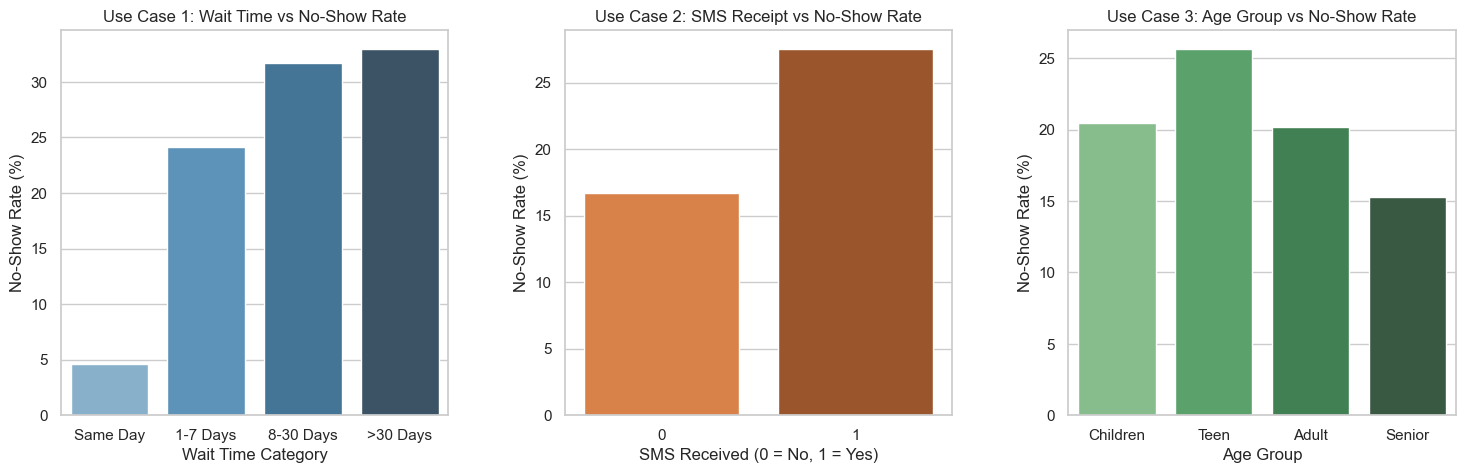

In [8]:
# Set up the canvas for 3 subplots
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plt.subplots_adjust(wspace=0.3)

# ---------------------------------------------------------
# USE CASE 1: Wait Days versus No-Show
# ---------------------------------------------------------
# Group wait_days into categories for visualization
final_df['wait_category'] = pd.cut(final_df['wait_days'], 
                                    bins=[-1, 0, 7, 30, 999], 
                                    labels=['Same Day', '1-7 Days', '8-30 Days', '>30 Days'])

wait_summary = final_df.groupby('wait_category')['is_no_show'].mean() * 100
sns.barplot(x=wait_summary.index, y=wait_summary.values, ax=axes[0], palette='Blues_d')
axes[0].set_title('Use Case 1: Wait Time vs No-Show Rate')
axes[0].set_ylabel('No-Show Rate (%)')
axes[0].set_xlabel('Wait Time Category')

# ---------------------------------------------------------
# USE CASE 2: SMS Reminder Effectiveness
# ---------------------------------------------------------
sms_summary = final_df.groupby('sms_received')['is_no_show'].mean() * 100
sns.barplot(x=sms_summary.index, y=sms_summary.values, ax=axes[1], palette='Oranges_d')
axes[1].set_title('Use Case 2: SMS Receipt vs No-Show Rate')
axes[1].set_ylabel('No-Show Rate (%)')
axes[1].set_xlabel('SMS Received (0 = No, 1 = Yes)')

# ---------------------------------------------------------
# USE CASE 3: Age Demographics vs No-Show
# ---------------------------------------------------------
age_summary = final_df.groupby('age_group')['is_no_show'].mean() * 100
sns.barplot(x=age_summary.index, y=age_summary.values, ax=axes[2], palette='Greens_d')
axes[2].set_title('Use Case 3: Age Group vs No-Show Rate')
axes[2].set_ylabel('No-Show Rate (%)')
axes[2].set_xlabel('Age Group')

plt.show()

### 5.1 Business Use Case Insights

- Use Case 1 (Objective: Evaluate scheduling SOP): The insight is that same-day appointments have the lowest no-show rate. As the interval between scheduling and appointment increases, the no-show rate also increases. Business recommendation: consider an overbooking strategy for patients with long wait times.

- Use Case 2 (Objective: Assess SMS reminder program effectiveness): The surprising finding is that patients who received appointment reminders had a higher no-show rate than those who did not. Business recommendation: this does not necessarily mean SMS reminders are ineffective; it may indicate that reminders are being sent preferentially to high-risk patients or that the reminder system needs better management. Further evaluation of the SMS workflow is advised.

- Use Case 3 (Objective: Understand high-risk patient demographics): The insight is that the "Teen" and "Adult" age groups show the highest no-show rates compared to "Senior" or "Children." Business recommendation: target communication and engagement efforts at working-age patients to improve attendance discipline.